> <p><small>This notebook is made available subject to the licence and terms set out in <a href="https://creativecommons.org/licenses/by/4.0">https://creativecommons.org/licenses/by/4.0</a>.</small></p>

<img src="https://pub-bba109a9a6ac49e3b428cdca19c34363.r2.dev/LT-%20Session%201.jpg">

# 1.7 AI Long Activity 2 - Lab: Machine Learning Workflow (Teacher)

Connect the machine learning pipeline to learning, inference and evaluation.

60 minutes


## Overview

This notebook provides:
- Completed code for each pipeline stage.
- Suggested teacher commentary.
- Typical outputs and interpretation.
- Notes on common student errors.

The model is evaluated on a **held-out test set**, not on the same data used for training. This makes the activity consistent with the idea of **generalization**.

### What you'll learn:

- Identify the main stages of the machine learning pipeline.
- Explain how preprocessing affects model performance.



## 1. Load dataset

Students upload the dataset manually. The dataset contains CO₂ emissions and related features for African countries over several years.

> 📝 **Teacher notes**
> - Common issues: missing values, inconsistent formatting,  heterogeneous scales.
> - Ask students to identify the target variable before doing anything else.
> - Remind them that a dataset must be inspected before modelling.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("co2_emissions_africa.csv")

df.head()

,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,2000,30774621,1780.38,8510.36,2381741,16.85,80.62,80.05,0.0,6.16,0.57,3.79,14.75,76.26,29.17,1.96,9.33
1,Algeria,Northern Africa,DZA,2001,31200985,1754.58,8840.67,2381741,17.04,76.24,78.65,0.0,6.25,-2.41,3.77,11.86,74.88,30.20,1.98,9.53
2,Algeria,Northern Africa,DZA,2002,31624696,1794.81,9354.22,2381741,19.36,80.00,82.40,0.0,6.62,-2.41,4.06,10.20,78.35,32.28,2.17,9.89
3,Algeria,Northern Africa,DZA,2003,32055883,2117.05,10088.09,2381741,21.76,85.78,88.19,0.0,7.01,-2.41,4.03,12.17,84.16,32.53,1.89,10.68
4,Algeria,Northern Africa,DZA,2004,32510186,2624.80,10653.34,2381741,22.03,87.09,89.49,0.0,8.09,-2.41,4.90,11.22,84.60,31.75,2.19,11.52


## 2. Inspect data

> 📝 **Teacher notes**
> - Encourage students to describe each variable.
> - Ask: which features make sense as predictors? Which ones might introduce noise?
> - Prompt students to distinguish between **inputs** and **outputs**.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1134 non-null   str    
 1   Sub-Region                              1134 non-null   str    
 2   Code                                    1134 non-null   str    
 3   Year                                    1134 non-null   int64  
 4   Population                              1134 non-null   int64  
 5   GDP PER CAPITA (USD)                    1107 non-null   float64
 6   GDP PER CAPITA PPP (USD)                1086 non-null   float64
 7   Area (Km2)                              1134 non-null   int64  
 8   Transportation (Mt)                     1122 non-null   float64
 9   Total CO2 Emission including LUCF (Mt)  1134 non-null   float64
 10  Total CO2 Emission excluding LUCF (Mt)  1134 non-null   float64
 11  Ot

## 3. Handle missing values

Here use a simple strategy: **mean imputation** for numerical variables.

> 📝 **Teacher notes**
> - This is not always the best method, but it is easy to understand and implement.
> - Alternative strategies:
>    - median imputation
>    - dropping rows
>    - using another model to predict missing values
> - Discussion point: preprocessing choices can affect final model performance.

In [ ]:
df_clean = df.fillna(df.mean(numeric_only=True))

df_clean.head()

,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,2000,30774621,1780.38,8510.36,2381741,16.85,80.62,80.05,0.0,6.16,0.57,3.79,14.75,76.26,29.17,1.96,9.33
1,Algeria,Northern Africa,DZA,2001,31200985,1754.58,8840.67,2381741,17.04,76.24,78.65,0.0,6.25,-2.41,3.77,11.86,74.88,30.20,1.98,9.53
2,Algeria,Northern Africa,DZA,2002,31624696,1794.81,9354.22,2381741,19.36,80.00,82.40,0.0,6.62,-2.41,4.06,10.20,78.35,32.28,2.17,9.89
3,Algeria,Northern Africa,DZA,2003,32055883,2117.05,10088.09,2381741,21.76,85.78,88.19,0.0,7.01,-2.41,4.03,12.17,84.16,32.53,1.89,10.68
4,Algeria,Northern Africa,DZA,2004,32510186,2624.80,10653.34,2381741,22.03,87.09,89.49,0.0,8.09,-2.41,4.90,11.22,84.60,31.75,2.19,11.52


## 4. Define features and target

You now choose:
- the **target** you want to predict
- the **features** used as inputs

> 📝 **Teacher notes**
> - Students often forget to remove the target from the feature list.
> - Encourage reasoning around causality vs correlation.
> - A model may use correlated variables without giving a causal explanation.

In [ ]:
target = df_clean["Total CO2 Emission including LUCF (Mt)"]
features = df_clean.select_dtypes(include=["float64", "int64"]).drop(columns=["Total CO2 Emission including LUCF (Mt)"])

features.head()

,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,2000,30774621,1780.38,8510.36,2381741,16.85,80.05,0.0,6.16,0.57,3.79,14.75,76.26,29.17,1.96,9.33
1,2001,31200985,1754.58,8840.67,2381741,17.04,78.65,0.0,6.25,-2.41,3.77,11.86,74.88,30.20,1.98,9.53
2,2002,31624696,1794.81,9354.22,2381741,19.36,82.40,0.0,6.62,-2.41,4.06,10.20,78.35,32.28,2.17,9.89
3,2003,32055883,2117.05,10088.09,2381741,21.76,88.19,0.0,7.01,-2.41,4.03,12.17,84.16,32.53,1.89,10.68
4,2004,32510186,2624.80,10653.34,2381741,22.03,89.49,0.0,8.09,-2.41,4.90,11.22,84.60,31.75,2.19,11.52


## 5. Train-test split

Split the data into:
- **training data** → used to fit the model
- **test data** → used to evaluate performance on unseen examples

This is essential to avoid overestimating model quality.

> 📝 **Teacher notes**
> - If students evaluate on the same data used for training, performance will often look artificially strong.
> - This is the main notebook change requested in feedback.
> - Key idea: **training = learning**, **test = evaluation**.

In [ ]:
from sklearn.model_selection import train_test_split

X = features
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

NameError: name 'features' is not defined

## 6. Train a simple model

Use **Linear Regression** as a baseline model.

> 📝 **Teacher notes**
> - Linear models are interpretable and fast.
> - Good first choice for this activity because students can focus on the workflow.
> - Useful opportunity to discuss limitations:
>   - non-linearity
>   - interactions between variables
>   - sensitivity to outliers

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:10]

array([127.11054273,   0.6003596 ,  12.21959859,  12.65917023,
        13.85850957,   3.27002905,  11.68058391,  15.89952614,
        57.25963726, 446.32212633])

## 7. Evaluate model performance

Students should compare **MAE** and **MSE**.

- **MAE**: more robust to outliers
- **MSE**: penalises large errors more heavily

> 📝 **Teacher notes**
> - Ask students why these two metrics may rank models differently.
> - Prompt them to think about which metric matters more for different users.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.0023910074069693216
MSE: 1.8042590528176374e-05


## 8. Visualise predictions

These plots help students interpret model behaviour rather than treating metrics as abstract numbers.

> 📝 **Teacher notes**
> - Encourage students to look for systematic errors.
> - Ask whether large true values are predicted well or badly.
> - The purpose is interpretation, not perfect plotting.

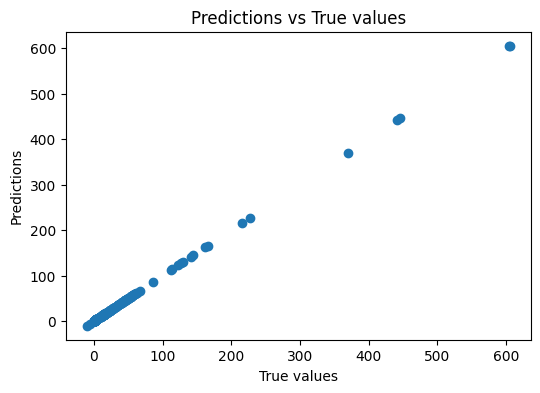

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("Predictions vs True values")
plt.show()

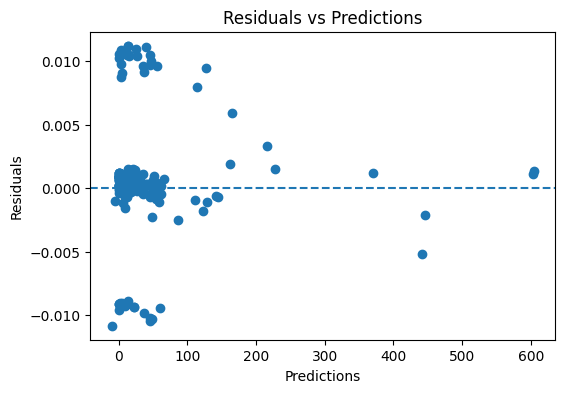

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

## 9. Interpretation prompts

Use the questions below for class discussion:

- Are predictions close to the true values?
- Do you observe large errors or outliers?
- Are errors evenly distributed?
- Which metric, MAE or MSE, better reflects performance here?
- Which metric might matter more to a policymaker? A climate scientist? A business?

> 📝 **Teacher notes**
> - This is where students connect the workflow to real-world decision-making.
> - Reinforce the link to asymmetry: some errors matter more than others.

## 10. Optional extension – Compare with another model

If time allows, compare linear regression with a decision tree.

> 📝 **Teacher notes**
> - This provides a natural bridge to model comparison.
> - Students may observe that a more flexible model can fit better, but also risks overfitting.
> - Keep the focus on interpretation rather than optimization.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Tree MAE:", mean_absolute_error(y_test, y_pred_tree))
print("Tree MSE:", mean_squared_error(y_test, y_pred_tree))

Tree MAE: 10.457663839350275
Tree MSE: 218.35878391043795


## 11. Teacher guidance

Typical teacher prompts:
- “Is this error on training data or test data?”
- “Would you trust this model on a new African country not seen in training?”
- “Does the plot suggest the model misses some part of the pattern?”

Expected interpretation:
- MAE is often easier to explain because it is in the same unit as the target.
- MSE is usually larger because errors are squared.
- A model should be judged on performance on **new data**, not only on training data.

Key concept to reinforce:
A machine learning workflow is not only about fitting a model. It includes:
1. data preparation
2. feature/target definition
3. train-test splitting
4. training
5. evaluation
6. interpretation

> 💭 **Reflection:**
>
> Ask students to write a short response:
>
> - Where does **learning** happen in this pipeline?
> - Where does **evaluation** happen?
> - Why is the **test set** essential?
> - Which pipeline step had the biggest impact on performance?
>
> **Closing message**
> A model should not be judged by how well it fits the training data, but by how well it performs on new, unseen data.